# Probability Foundations

## 1. Retrieval -PCA and linear algebra

### 1. Covariance matrix structure
    
For a dataset with 3 features, what does each of the following represent in its `3×3` covariance matrix?
- a diagonal entry such as $\Sigma_{11}$
- an off-diagonal entry such as $\Sigma_{12}$
	​

### 2. Eigenvector vs eigenvalue

In the equation:

$$Σv=λv$$

what does $v$ represent geometrically, and what does $\lambda$ represent when $\Sigma$ is a covariance matrix?

### 3. Why centre before PCA?

Suppose you translate every observation in a dataset by adding [100, 100, 100]. The shape and spread of the cloud do not change. Explain why PCA should first subtract the feature means before analysing variance.

### 4. What does the PCA multiplication do?

Suppose:

- `X_centered.shape == (150, 3)`
- `W.shape == (3, 2)`
- the two columns of `W` are PC1 and PC2.

You calculate:

`Z = X_centered @ W`

What is the shape of `Z`, and what does:

`Z[:, 0]`

represent geometrically?

### 5. Why does PC variance equal its eigenvalue?

`Z[:, 0]` contains every observation’s coordinate along PC1. Explain in words why:

`np.var(Z[:, 0], ddof=1)`

should equal the eigenvalue associated with PC1.

### 6. Why is PCA-coordinate covariance diagonal?
Suppose:

$$\begin{bmatrix} 12.4&0 \cr 0&0.8 \end{bmatrix}$$

Explain:

- what 12.4 means;
- what 0.8 means;
- why the off-diagonal entries are approximately zero.

Then explain what is meant by the statement:

“The covariance matrix is diagonal in the principal-component basis.”

### 7. Reconstruction
You reduce three original features to two PCs:

`Z = X_centered @ W`

where `W.shape == (3, 2)`.

Explain what:

$$ZW^{T}$$

represents. Why is it generally not exactly equal to `X_centered` when only two PCs are retained?

Finally, why do we add the original feature mean:

$$X_{reconstructed} = ZW^{T} + \mu$$

### 8. Sorting eigenpairs with NumPy
Given:

`eigenvalues = np.array([0.4, 8.2, 1.7])`

answer these before running any code:

- What should `np.argsort(eigenvalues)` return?
- What should `np.argsort(eigenvalues)[::-1]` return?
- If those descending indices are stored in `idx`, why must you use the same idx for both:
  - `eigenvalues[idx]`
  - `eigenvectors[:, idx]`

## 2. Answers

### 1. 
- The diagonal entries represent the variance of each of the features, so $\Sigma_{11}$ represents $var(feat_1)$
- An off-diagonal entry represents the covariance between two of the features, so $\Sigma_{12}$ represents $cov(feat_1, feat_2)$

### 2. 
- $v$ is an eigenvector of the covariance matrix and represents a direction in feature space along which the data varies.
- $\lambda$ represents the eigenvalue for the eigenvector $v$ and it measures the amount of variance in the dataset along the eigenvector direction

### 3.
Without centering, the PCA calculation could become influenced by the dataset's displacement from the origin, rather than purely by its internal variation. Centering places the mean at the origin so the covariance matrix describes how observations vary around their mean.

### 4.
`Z.shape == (150, 2)` and `Z[:, 0]` represents the 150 scalar coordinates of the observations projected along PC1.

### 5.
Since `Z[:, 0]` represents dataset projected along PC1, the variance of `Z[:, 0]` measures how much the dataset varies along PC1. The corresponding eigenvalue of the feature-space covariance matrix also represents the variance along this principal component direction, therefore **the variance of each principal component should equal its eigenvalue**.

### 6. 
- 12.4 is the eigenvalue of the eigenvector corresponding to PC1, and is also the variance of the data along the PC1 axis in PCA coordinate space.
- 0.8 is the eigenvalue of the eigenvector corresponding to PC2, and is also the variance of the data along the PC2 axis in PCA coordinate space.
- off-diagonal entries are $\approx0$ because the PCA-coordinate system uses a basis where each axis is chosen so that the projected coordinates along different principal components have zero covariance. Therefore the principal components are uncorrelated.
- When the data is expressed using the principal-component axes instead of the original feature axes, its covariance matrix contains the PC variances on the diagonal and zero cross-covariances off the diagonal:
$$W^T \Sigma W = \Lambda$$

### 7.
Because only PC1 and PC2 were retained, Z contains no coordinate along PC3. When we reconstruct with $ZW^T$, the component of each observation in the PC3 direction cannot be recovered. The variance associated with $\lambda_3$ has therefore been discarded.

Adding the original feature mean returns the reconstructed dataset to its non-centered allignment to best match the original input data.

### 8.
- an array of indices corresponding to eigenvalues sorted smallest to largest
- an array of indices corresponding to eigenvalues sorted largest to smallest
- to prevent the eigenvectors from becoming decoupled from their corresponding eigenvalues. We do not want the code to lose track of which eigenvalue corresponds with each eigenvector

## 3. Probability and events

### Learn

For an experiment, the **sample space $\Omega$** is the set of every possible outcome.

For one six-sided dice:

$$\Omega=\{1,2,3,4,5,6\}$$

An **event** is a subset of those outcomes. For example:

$$A = \{even~roll\}=\{2,4,6\}$$

The main notation:

$$P(A)$$

means the probability that event A occurs.

$$A \cap B$$

means **A and B both occur**.

$$A \cup B$$

means **A or B occurs, including both**

$$A^{c}$$

means **A does not occur**.

For equally likely outcomes:

$$P(A)= \frac{number~of~outcomes~in~A}{number~of~outcomes~in~\Omega}


### Exercise 1 — Events on one die

Consider rolling one fair six-sdied die.

Define:
- A = roll is even
- B = roll is atleast 4

Without writing Python first:

1. Write the sample space $\Omega$.

>$\Omega = \{1,2,3,4,5,6\}$

2. List the outcomes belonging to $A$.

> $A = \{2,4,6\}$

3. List the outcomes belonging to $B$.

>$ B = \{4,5,6\}$

4. Find $A\cap B$.

> $\{4,6\}$

5. Find $A\cup B$.

> $\{2,4,5,6\}$

6. Find $A^c$.

> $\{1,3,5\}$

7. Calculate:
    - $P(A) \rarr \frac{3}{6} = \frac{1}{2}$ 
    - $P(B) \rarr \frac{3}{6} = \frac{1}{2}$ 
    - $P(A\cap B) \rarr \frac{2}{6} = \frac{1}{3}$
    - $P(A\cup B) \rarr \frac{4}{6} = \frac{2}{3}$

In [34]:
p_union_A_B = 1/2 + 1/2 - 1/3
print(p_union_A_B)

0.6666666666666667


> The intersection has to be subtracted in the equation
> $$P(A\cup B) = P(A) + P(B) - P(A\cap B)$$
> because the probability that either A or B will occur is covered by $P(A) + P(B)$, however this will count events where *both* A and B occur twice, therefore we must also subtract from the probability that both events occur, i.e., the intersection must be subtracted

## Random variables and probability distributions

### Learn

An *outcome* and a *random variable* are not the same thing. Suppose we roll two dice.

One outcome might be: $$(3,5)$$ Now define: $$X = sum~of~the~two~dice$$ For that outcome: $$X=8$$ So:

- **outcome** $\rarr (3,5)$
- **random variable** $X \rarr 8$

A **probability distribution** tells us the probability of each possible value of $X$.

For two dice: $$X \in\{2,3,...,12\}$$

### Exercise 2 — Build the distribution of two-dice sums

First, construct all 36 ordered outcomes of rolling two six-sided dice. You can use loops here. Don't worry about making this maximally NumPy-like.

You should end up with information equivalent to:

```
(1, 1)
(1, 2)
...
(6, 5)
(6, 6)
```
Then calculate the sum for every outcome.

In [35]:

import numpy as np

dice_rolls = []
possible_sums = np.zeros(11)
probabilities = np.zeros(11)

for i in range(6):
  for j in range(6):
    dice_rolls.append([i+ 1, j + 1])
    possible_sums[i + j] = i + j + 2
    probabilities[i + j] += 1/(6**2)

print('sum of all probabilities == 1:', np.allclose(np.sum(probabilities), 1))
print('possible_sums shape:', np.shape(possible_sums))
print('probabilities shape:', np.shape(probabilities))


sum of all probabilities == 1: True
possible_sums shape: (11,)
probabilities shape: (11,)


Text(0, 0.5, 'Probability')

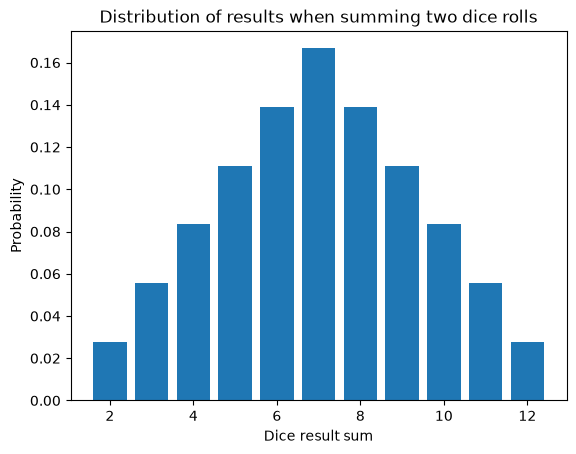

In [36]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

ax.bar(possible_sums, probabilities)
ax.set_title('Distribution of results when summing two dice rolls')
ax.set_xlabel('Dice result sum')
ax.set_ylabel('Probability')

1. Which sums are most likely?

> 7 is the most likely outcome

2. Which sums are least likely?

> 2 and 12 are the least likely outcomes

3. Why is the distribution symmetric?

> Because the outcomes for either dice are equally distributed between 1-6

4. Why aren't all sums equally probable even though each individual die is fair?

> Because some outcomes can be achieved using multiple combinations of dice rolls

### Exercise 3 — Simulate the same experiment

Now simulate instead of enumerating.

In [37]:
rng = np.random.default_rng(88)
n_rolls = 100_000

Generate:

```
die_1
die_2
```

each containing 100_000 random integers from 1 through 6.

Text(0, 0.5, 'Probability')

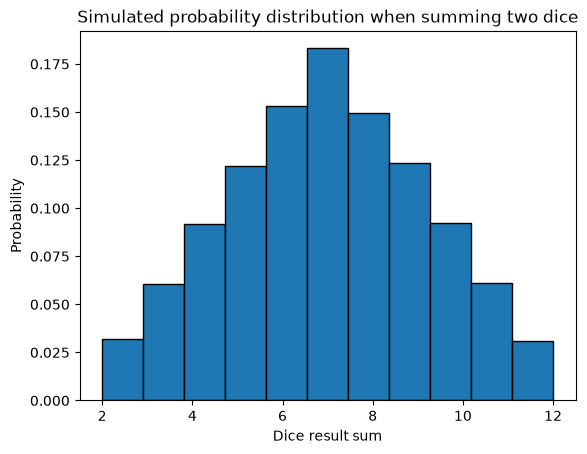

In [38]:
die_1 = np.zeros(n_rolls)
die_2 = np.zeros(n_rolls)

die_1 = rng.integers(low=1, high=7, size=n_rolls)
die_2 = rng.integers(low=1, high=7, size=n_rolls)
outcomes = np.add(die_1, die_2)

fig, ax = plt.subplots()
ax.hist(outcomes, bins = 11, density = True, edgecolor='black')
ax.set_title('Simulated probability distribution when summing two dice')
ax.set_xlabel('Dice result sum')
ax.set_ylabel('Probability')

Why do the simulated probabilities get close to the theoretical probabilities but not match them exactly?

> The higher the `n_rolls` the closer to the theoretical probabilities the simulated probabilities will get, however due to the random nature of rng it is very unlikely for the simulated results to match the theoretical results *exactly*

## 5. Expectation and variance

### Learn

For a discrete random variable $X$, its **expected value** is: $$E[X]=\sum_x xP(X=x)$$ This is a probability-weighted mean.

Importantly: **the expected value is not necessarily a value that must actually occur in one trial**

Variance measures how far values tend to lie from the expectations: $$Var(X)=\sum_x (x-E[X])^{2}P(X=x)$$ You can also calculate it using: $$Var(X) = E[X^{2}]-E[X]^{2}$$

### Exercise 4 — Expectation of the dice sum

Using your arrays from Exercise 2:

```
possible_sums
probabilities
```

calculate the theoretical expected value:

$$E[X]$$

Do this using NumPy array operations — **not a loop**.

In [39]:
expected_outcome = np.sum(possible_sums * probabilities)
print(f'Theoretical expectation ={expected_outcome: .6f}')

simulated_mean = np.mean(outcomes)
print(f'Simulation mean:{simulated_mean: .6f}')

print(f'Difference: {abs(expected_outcome-simulated_mean)}')

Theoretical expectation = 7.000000
Simulation mean: 7.000260
Difference: 0.0002600000000017033


Explain why the simulated mean should be close to the theoretical expectation.

> Since n_rolls is so high, we expect the results from the simulation to very closely match the theoretical expectation. There would be a greater difference with a lower n_rolls

### Exercise 5 — Variance two ways

Using the theoretical probability distribution, calculate variance using:

#### Method A
$$\sum_x (x-E[X])^{2}P(X=x)$$

#### Method B
$$E[X^{2}]-E[X]^{2}$$


Do not use np.var() for these first two calculations.

In [40]:
import math

# Method A
variance_a = np.sum((possible_sums - expected_outcome)**2 * probabilities)
print('variance_a:', variance_a)

# Method B
variance_b = np.sum(possible_sums**2 * probabilities) - expected_outcome**2
print('variance_b:', variance_b)
print('variance_a approximateley equals variance_b:', np.allclose(variance_a, variance_b))

variance_c = np.var(outcomes)
print(variance_c)
print('simulated variance approximateley equals theoretical variance:', np.allclose(variance_a, variance_c))

theoretical_stddev = math.sqrt(variance_a)
print('theoretical standard deviation:', theoretical_stddev)

variance_a: 5.833333333333333
variance_b: 5.833333333333364
variance_a approximateley equals variance_b: True
5.8733599324
simulated variance approximateley equals theoretical variance: False
theoretical standard deviation: 2.41522945769824


1. What does the expected value tell you about this distribution?

> The most likely result from this distribution is 7

2. What does its variance tell you?

> How spread out the possible outcomes are from the expected result

3. Why do we square deviations when calculating variance?

> Squaring results in a higher penalty for datapoints that are further away from the expected outcome

4. What relationship does standard deviation have to variance?

> $\sigma^{2} = Variance$

## 6. Joint probability, conditional probability and independence

### Learn

For two events: $$P(A\cap B$$ means:

> probability that **both A and B happen**.

Conditional probability: $$P(A|B)=\frac{P(A\cap B)}{P(B)}$$ means:

> probability of A **given that we already know B happened**

Notice that knowing $B$ changes the population we're considering. Instead of asking:

> How many of all 36 outcomes satisfy $A$>

we ask:

> Among only the outcomes satisfying B, how many also satisfy A?

Two events are **independent** when knowing one occurred gives no information about the other.

One mathematical test for independence is: $$P(A\cap B)=P(A)P(B)$$

### Exercise 6 — Conditional probability from two dice

Reuse your 36 possible ordered dice outcomes.

Define:

```
A = first die is even
B = total sum is at least 8
```

Calculate exactly:
- $P(A)$
- $P(B)$
- $P(A\cap B)$

Then calculate:
- $P(A|B)$
- $P(B|A)$

In [41]:
dice_rolls_array = np.array(dice_rolls)

A = dice_rolls_array[:, 0] % 2 == 0
B = np.sum(dice_rolls_array, axis=1) >= 8
A_and_B = A & B

prob_a = np.sum(A) / len(dice_rolls_array)
prob_b = np.sum(B) / len(dice_rolls_array)
prob_a_and_b = np.sum(A_and_B) / len(dice_rolls_array)

print('P(A):', prob_a)
print('P(B):', prob_b)
print('P(A ∩ B):', prob_a_and_b)


P(A): 0.5
P(B): 0.4166666666666667
P(A ∩ B): 0.25


In [42]:
prob_a_given_b = prob_a_and_b / prob_b
prob_b_given_a = prob_a_and_b / prob_a

print('P(A|B):', prob_a_given_b)
print('P(B|A):', prob_b_given_a)

P(A|B): 0.6
P(B|A): 0.5


1. Explain in words what P(A∣B) means for this experiment.

> $P(A|B)$ means the probability that the first dice roll was an even number given that the sum of the two dice rolls was at least 8. This means that if the sum of the dice roll was $\geq 8$ the probability of rolling an even number for the first roll is higher than in unrestrcited dice roll scenario: $P(A|B) > P(A)$

2. Explain why P(A∣B) and P(B∣A) are answering different questions.

> $P(A|B)$ is asking the probability of rolling an even number for the first dice in a population where the sum of the two rolls is $\geq 8$, while $P(B|A)$ is asking the probability that the sum of the two rolls is $\geq 8$ in a population where the first roll is an even number. The latter is greater than $P(B)$ in the full population since we are effectivley increasing the expected result of the first dice roll by removing the odd roll possible combinations (expected result for all numbers = (1+ 2 + 3 + 4 + 5 + 6) / 6 = 3.5, compared to expected result forall numbers = (1 + 2 + 3 + 4 + 5 + 6) / 6 = 3.5), which means that $P(B|A) > P(B)$

3. Check whether: $$P(A\cap B)=P(A)P(B)$$


In [43]:
print('P(A ∩ B) = P(A) x P(B):', prob_a_and_b == prob_a * prob_b)

P(A ∩ B) = P(A) x P(B): False


4. Are $A$ and $B$ independent?

> $A$ and $B$ are not independent since $P(A\cap B) \neq P(A)P(B)$

### Exercise 7 — Compare with genuinely independent events

Now define:
```
C = first die is even
D = second die is at least 4
```

Calculate:
- $P(C)$
- $P(D)$
- $P(C\cap D)$
- $P(C | D)$

Then test: $$P(C\cap D)\stackrel{?}{=}P(C)P(D)$$


In [ ]:
C = dice_rolls_array[:, 0] % 2 == 0
D = dice_rolls_array[:, 1] >= 4
C_and_D = C & D

prob_c = np.sum(C)/len(dice_rolls_array)
prob_d = np.sum(D) / len(dice_rolls_array)
prob_c_and_d = np.sum(C_and_D) / len(dice_rolls_array)
prob_c_given_d = prob_c_and_d / prob_d

print('P(C):', prob_c)
print('P(D):', prob_d)
print('P(C ∩ D):', prob_c_and_d)
print('P(C|D):', prob_c_given_d)

print('P(C ∩ D) = P(C) x P(D):', prob_c_and_d == prob_c * prob_d)

P(C): 0.5
P(D): 0.5
P(C ∩ D): 0.25
P(C|D): 0.5
P(C ∩ D) = P(C) x P(B): True


1. Are C and D independent?

> C and D **are independent**

2. What happens to P(C) when you learn that D occurred?

> It does not change

3. Contrast this result with Exercise 6.

> The events were not independent in Ex 6, therefore knowledge of one of the events occurring affected the probability that the other event had also occurred, wherease in this exercise knowledge of one events occurence does not effect the probability that the other has occurred, therefore the events are independent.

## 7. End-of-session check

Answer briefly:

1. What is the difference between an outcome, an event, and a random variable?

> An outcome is a possible result from a sample space, an event is a subset of those outcomes, and a random variable is a function that maps each possible outcome in the sample space to a numbert.

2. What does a probability distribution describe?

> A probability distribution tells us the probability of each possible value of a random variable.

3. What does E[X] represent?

> The probability-weighted long-run average value of $X$

4. What does Var(X) represent?

> How much a random variable $X$ is spread out around the expected result

5. Explain the difference between: $$P(A∩B)$$ and $$P(A∣B)$$

> $P(A∩B)$ means the probability of both A **and** B occurring, while $P(A|B)$ is the probability of A occurring when looking at a subset of the total population in which B has occurred.

6. What condition can you use to test whether two events are independent?

> If $$P(C\cap D)=P(C)P(D)$$ then the events are independent

7. Suppose P(A)=0.4 but P(A∣B)=0.7. What does that tell you about whether knowing B gives information about A?

> This tells you that knowing B affects the probability that A is true. Specifically, if B is true then A is also more likely to be true compared to the probability of A in the total population
